# Lab 04: Speech Analyzer

## Necessary imports

In [1]:
import requests
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

## Task 1

In [3]:
# Download the required NLTK data files (only needs to be run once)
nltk.download('punkt')
nltk.download('punkt_tab') # Sometimes required depending on your NLTK version

# 1. Download the speech text from the URL
url = "https://raw.githubusercontent.com/masterfloss/text/refs/heads/main/jobs.txt"
response = requests.get(url)
speech_text = response.text

# 2. Tokenize the speech into sentences using NLTK
sentences = sent_tokenize(speech_text)

# Tokenize into words (filtering out punctuation to get an accurate word count)
words = [word for word in word_tokenize(speech_text) if word.isalnum()]

# 3. Count the total number of words in the speech
total_words = len(words)

# 4. Count the total number of sentences
total_sentences = len(sentences)

# Print the counts
print(f"Total number of words: {total_words}")
print(f"Total number of sentences: {total_sentences}\n")

# 5. Display the first five sentences to verify correct tokenization
print("--- First 5 Sentences ---")
for i, sentence in enumerate(sentences[:5]):
    print(f"{i + 1}: {sentence}")

[nltk_data] Downloading package punkt to /Users/amyqian/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amyqian/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total number of words: 2240
Total number of sentences: 146

--- First 5 Sentences ---
1: I am honored to be with you today at your commencement from one of the finest universities in the world.
2: I never graduated from college.
3: Truth be told, this is the closest I've ever gotten to a college graduation.
4: Today I want to tell you three stories from my life.
5: That's it.


## Task 2

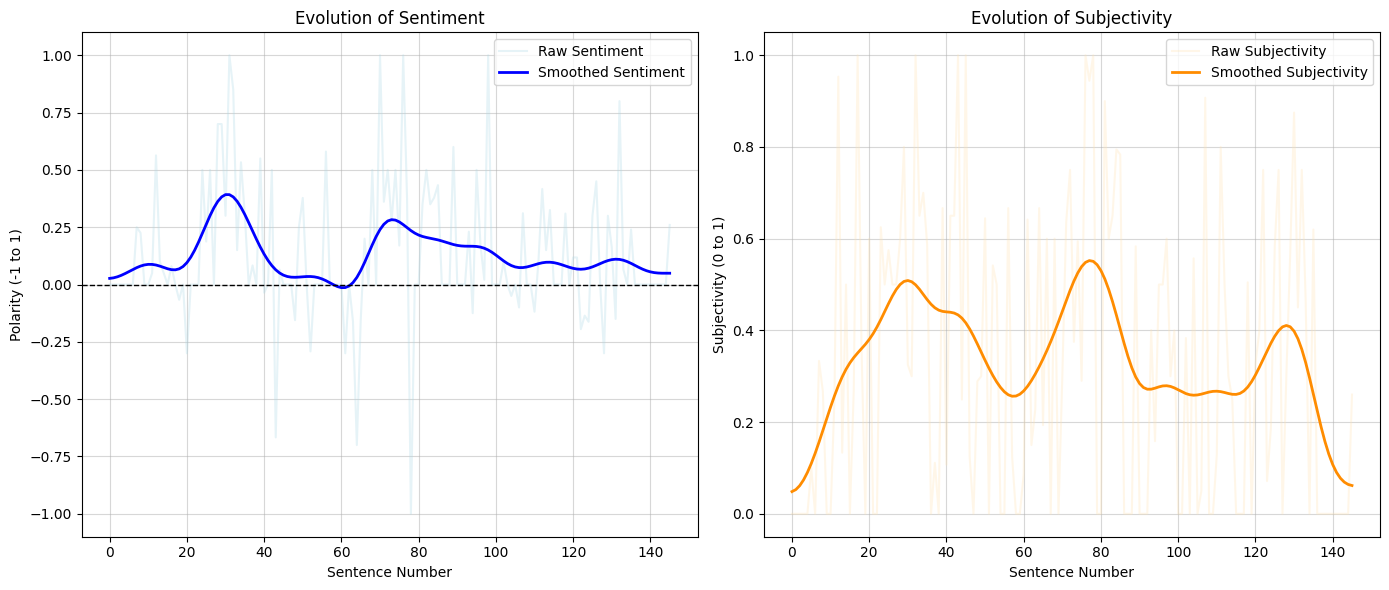

In [ ]:
# 1 & 2. Compute sentiment polarity and subjectivity for each sentence
polarities = []
subjectivities = []

for sentence in sentences: # 'sentences' is from Task 1
    blob = TextBlob(sentence)
    polarities.append(blob.sentiment.polarity)
    subjectivities.append(blob.sentiment.subjectivity)

# 4. Apply Gaussian smoothing to highlight trends
# The 'sigma' parameter should be adjusted to control the amount of smoothing.
sigma_value = 5 
smoothed_polarities = gaussian_filter1d(polarities, sigma=sigma_value)
smoothed_subjectivities = gaussian_filter1d(subjectivities, sigma=sigma_value)

# 3 & 5. Plot the evolution of sentiment and smoothed subjectivity
plt.figure(figsize=(14, 6))

# Subplot 1: Sentiment
plt.subplot(1, 2, 1)
plt.plot(polarities, alpha=0.3, label='Raw Sentiment', color='lightblue')
plt.plot(smoothed_polarities, label='Smoothed Sentiment', color='blue', linewidth=2)
plt.title('Evolution of Sentiment')
plt.xlabel('Sentence Number')
plt.ylabel('Polarity (-1 to 1)')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Adds a baseline at neutral 0
plt.legend()
plt.grid(True, alpha=0.5)

# Subplot 2: Subjectivity
plt.subplot(1, 2, 2)
plt.plot(subjectivities, alpha=0.3, label='Raw Subjectivity', color='moccasin')
plt.plot(smoothed_subjectivities, label='Smoothed Subjectivity', color='darkorange', linewidth=2)
plt.title('Evolution of Subjectivity')
plt.xlabel('Sentence Number')
plt.ylabel('Subjectivity (0 to 1)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Task 3

--- Top 10 Words per Topic ---

Topic 1:
looking, just, dropped, life, connect, later, years, computer, dots, company

Topic 2:
college, life, apple, months, did, work, didn, parents, decided, love

Topic 3:
don, death, stay, life, know, want, years, die, heart, ll


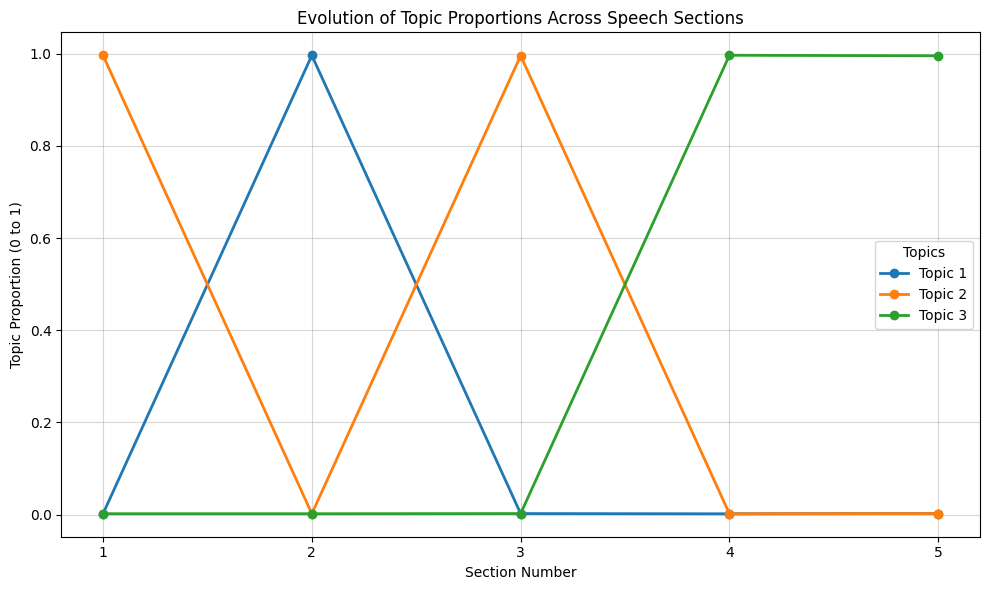

In [5]:
# 1. Divide the speech into 5 sections of roughly equal length
num_sections = 5
section_size = len(sentences) // num_sections
sections = []

for i in range(num_sections):
    # For the last section, grab all remaining sentences to avoid leaving any out
    if i == num_sections - 1:
        chunk = sentences[i * section_size:]
    else:
        chunk = sentences[i * section_size : (i + 1) * section_size]
    # Join the sentences back into a single block of text for the section
    sections.append(" ".join(chunk))

# 2. Use CountVectorizer to create a document-term matrix
# We remove common 'english' stop words (like 'the', 'is', 'and') so they don't dominate the topics
vectorizer = CountVectorizer(stop_words='english')
dtm = vectorizer.fit_transform(sections)

# 3. Fit a Latent Dirichlet Allocation (LDA) model to identify 3 main topics
num_topics = 3
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(dtm)

# 4. For each topic, list the top 10 words
feature_names = vectorizer.get_feature_names_out()

print("--- Top 10 Words per Topic ---")
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1}:")
    # Get the indices of the top 10 highest-weighted words for this topic
    top_word_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_word_indices]
    print(", ".join(top_words))

# 5. Plot the evolution of topic proportions across sections
# Transform the sections to get the distribution of topics for each section
topic_distributions = lda_model.transform(dtm)

plt.figure(figsize=(10, 6))

for topic_idx in range(num_topics):
    plt.plot(
        range(1, num_sections + 1), 
        topic_distributions[:, topic_idx], 
        marker='o', 
        linewidth=2, 
        label=f'Topic {topic_idx + 1}'
    )

plt.title('Evolution of Topic Proportions Across Speech Sections')
plt.xlabel('Section Number')
plt.ylabel('Topic Proportion (0 to 1)')
plt.xticks(range(1, num_sections + 1))
plt.legend(title="Topics")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Task 4

In [6]:
# Download required NLTK data (quiet=True prevents it from printing download logs every time)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [7]:
class SpeechReader:
    """Responsible for downloading and tokenizing the speech."""
    def __init__(self, url):
        self.url = url
        self.text = ""
        self.sentences = []
        self.words = []

    def download_and_tokenize(self):
        # Download
        response = requests.get(self.url)
        self.text = response.text
        
        # Tokenize sentences and words (filtering out punctuation)
        self.sentences = sent_tokenize(self.text)
        self.words = [word for word in word_tokenize(self.text) if word.isalnum()]
        
        return self.sentences

    def get_summary_stats(self):
        return len(self.words), len(self.sentences)

    def print_first_n_sentences(self, n=5):
        print(f"--- First {n} Sentences ---")
        for i, sentence in enumerate(self.sentences[:n]):
            print(f"{i + 1}: {sentence}")

In [9]:
class SpeechAnalyzer:
    """Responsible for computing sentiment, subjectivity, dividing into sections, and topic modeling."""
    def __init__(self, sentences):
        self.sentences = sentences

    def compute_sentiment_subjectivity(self):
        polarities = []
        subjectivities = []
        for sentence in self.sentences:
            blob = TextBlob(sentence)
            polarities.append(blob.sentiment.polarity)
            subjectivities.append(blob.sentiment.subjectivity)
        return polarities, subjectivities

    def divide_into_sections(self, num_sections=5):
        section_size = len(self.sentences) // num_sections
        sections = []
        for i in range(num_sections):
            if i == num_sections - 1:
                chunk = self.sentences[i * section_size:]
            else:
                chunk = self.sentences[i * section_size : (i + 1) * section_size]
            sections.append(" ".join(chunk))
        return sections

    def perform_topic_modeling(self, sections, num_topics=3):
        vectorizer = CountVectorizer(stop_words='english')
        dtm = vectorizer.fit_transform(sections)
        
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(dtm)
        
        feature_names = vectorizer.get_feature_names_out()
        topic_distributions = lda_model.transform(dtm)
        
        return lda_model, feature_names, topic_distributions

    def print_top_words(self, lda_model, feature_names, num_words=10):
        print("--- Top Words per Topic ---")
        for topic_idx, topic in enumerate(lda_model.components_):
            print(f"\nTopic {topic_idx + 1}:")
            top_word_indices = topic.argsort()[:-num_words - 1:-1]
            top_words = [feature_names[i] for i in top_word_indices]
            print(", ".join(top_words))

In [10]:
class SpeechVisualizer:
    """Responsible for plotting sentiment, subjectivity, and topic evolution."""
    @staticmethod
    def plot_sentiment_and_subjectivity(polarities, subjectivities, sigma=5):
        smoothed_polarities = gaussian_filter1d(polarities, sigma=sigma)
        smoothed_subjectivities = gaussian_filter1d(subjectivities, sigma=sigma)

        plt.figure(figsize=(14, 6))

        # Sentiment Subplot
        plt.subplot(1, 2, 1)
        plt.plot(polarities, alpha=0.3, label='Raw Sentiment', color='lightblue')
        plt.plot(smoothed_polarities, label='Smoothed Sentiment', color='blue', linewidth=2)
        plt.title('Evolution of Sentiment')
        plt.xlabel('Sentence Number')
        plt.ylabel('Polarity (-1 to 1)')
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.legend()
        plt.grid(True, alpha=0.5)

        # Subjectivity Subplot
        plt.subplot(1, 2, 2)
        plt.plot(subjectivities, alpha=0.3, label='Raw Subjectivity', color='moccasin')
        plt.plot(smoothed_subjectivities, label='Smoothed Subjectivity', color='darkorange', linewidth=2)
        plt.title('Evolution of Subjectivity')
        plt.xlabel('Sentence Number')
        plt.ylabel('Subjectivity (0 to 1)')
        plt.legend()
        plt.grid(True, alpha=0.5)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_topic_evolution(topic_distributions, num_topics=3):
        num_sections = topic_distributions.shape[0]
        plt.figure(figsize=(10, 6))

        for topic_idx in range(num_topics):
            plt.plot(
                range(1, num_sections + 1), 
                topic_distributions[:, topic_idx], 
                marker='o', 
                linewidth=2, 
                label=f'Topic {topic_idx + 1}'
            )

        plt.title('Evolution of Topic Proportions Across Speech Sections')
        plt.xlabel('Section Number')
        plt.ylabel('Topic Proportion (0 to 1)')
        plt.xticks(range(1, num_sections + 1))
        plt.legend(title="Topics")
        plt.grid(True, alpha=0.5)
        plt.tight_layout()
        plt.show()

In [11]:
class AdditionalAnalyzer:
    """Responsible for extended textual analysis: diversity, pacing, and vocabulary."""
    def __init__(self, words, sentences):
        self.words = [w.lower() for w in words] 
        self.sentences = sentences

    def compute_lexical_diversity(self):
        """Calculates the ratio of unique words to total words."""
        unique_words = set(self.words)
        return len(unique_words) / len(self.words)

    def compute_pacing(self):
        """Calculates average words per sentence and average characters per word."""
        avg_words_per_sentence = len(self.words) / len(self.sentences)
        avg_word_length = sum(len(word) for word in self.words) / len(self.words)
        return avg_words_per_sentence, avg_word_length

    def get_top_vocabulary(self, num_words=10):
        """Finds the most frequent words, excluding common stop words."""
        stop_words = set(stopwords.words('english'))
        meaningful_words = [w for w in self.words if w not in stop_words and len(w) > 1]
        freq_dist = FreqDist(meaningful_words)
        return freq_dist.most_common(num_words)

--- STEP 1: Reading & Preprocessing ---
Total number of words: 2240
Total number of sentences: 146

--- First 5 Sentences ---
1: I am honored to be with you today at your commencement from one of the finest universities in the world.
2: I never graduated from college.
3: Truth be told, this is the closest I've ever gotten to a college graduation.
4: Today I want to tell you three stories from my life.
5: That's it.


--- STEP 2: Computing Sentiment & Subjectivity ---
Generating Sentiment and Subjectivity Plots...



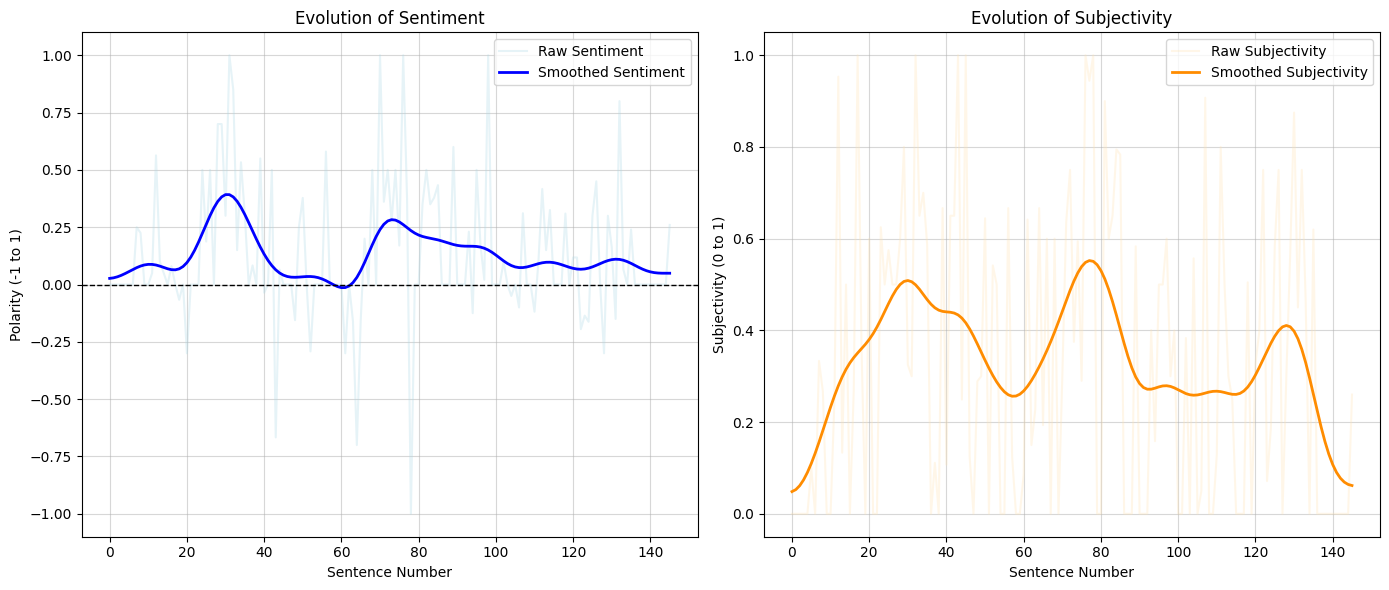

--- STEP 3: Topic Modeling Across Sections ---
--- Top Words per Topic ---

Topic 1:
looking, just, dropped, life, connect, later, years, computer, dots, company

Topic 2:
college, life, apple, months, did, work, didn, parents, decided, love

Topic 3:
don, death, stay, life, know, want, years, die, heart, ll

Generating Topic Evolution Plot...


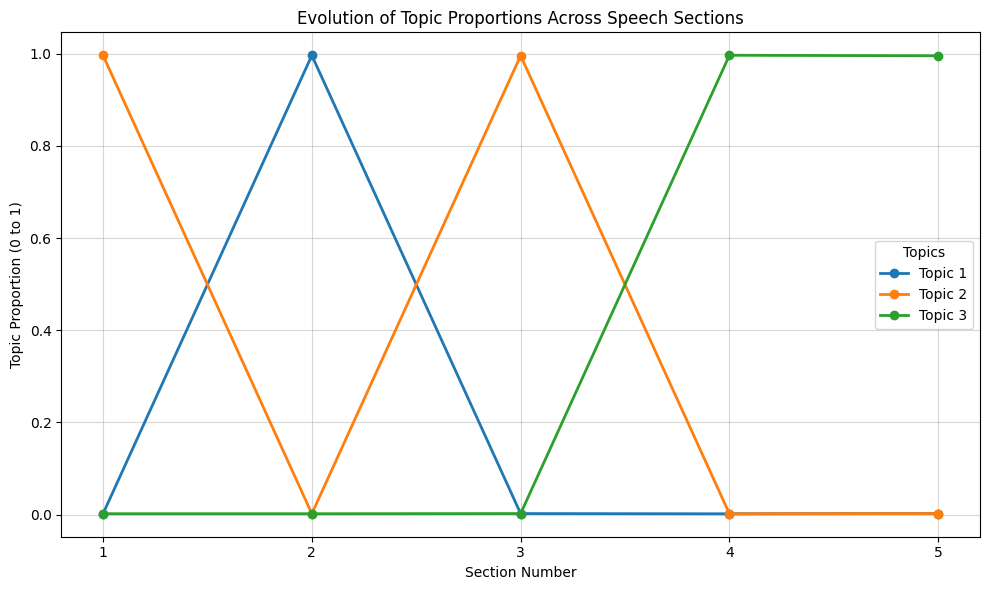



--- EXTRA: Additional Speech Metrics ---
Lexical Diversity: 30.58% unique words
Average Pacing: 15.3 words per sentence
Average Word Length: 4.09 characters per word

Top 10 Core Vocabulary Words:
 - life: 17 times
 - college: 14 times
 - one: 9 times
 - would: 9 times
 - years: 9 times
 - apple: 9 times
 - never: 8 times
 - dropped: 7 times
 - months: 7 times
 - later: 7 times


In [ ]:
# ==========================================
# MAIN EXECUTION 
# ==========================================
if __name__ == "__main__":
    url = "https://raw.githubusercontent.com/masterfloss/text/refs/heads/main/jobs.txt"

    # ------------------------------------------
    # STEP 1: Reading and Preprocessing
    # ------------------------------------------
    print("--- STEP 1: Reading & Preprocessing ---")
    reader = SpeechReader(url)
    sentences = reader.download_and_tokenize()
    total_words, total_sentences = reader.get_summary_stats()
    
    print(f"Total number of words: {total_words}")
    print(f"Total number of sentences: {total_sentences}\n")
    reader.print_first_n_sentences(5)
    print("\n" + "="*40 + "\n")

    # ------------------------------------------
    # STEP 2: Sentiment and Subjectivity
    # ------------------------------------------
    print("--- STEP 2: Computing Sentiment & Subjectivity ---")
    analyzer = SpeechAnalyzer(sentences)
    polarities, subjectivities = analyzer.compute_sentiment_subjectivity()
    print("Generating Sentiment and Subjectivity Plots...\n")
    
    visualizer = SpeechVisualizer()
    visualizer.plot_sentiment_and_subjectivity(polarities, subjectivities)

    # ------------------------------------------
    # STEP 3: Topic Modeling
    # ------------------------------------------
    print("--- STEP 3: Topic Modeling Across Sections ---")
    num_sections = 5
    num_topics = 3
    
    sections = analyzer.divide_into_sections(num_sections)
    lda_model, feature_names, topic_distributions = analyzer.perform_topic_modeling(sections, num_topics)
    
    analyzer.print_top_words(lda_model, feature_names)
    print("\nGenerating Topic Evolution Plot...")
    visualizer.plot_topic_evolution(topic_distributions, num_topics)
    print("\n" + "="*40 + "\n")

    # ------------------------------------------
    # EXTENSION: Additional Metrics
    # ------------------------------------------
    print("--- EXTRA: Additional Speech Metrics ---")
    extra_analyzer = AdditionalAnalyzer(reader.words, reader.sentences)
    
    lexical_diversity = extra_analyzer.compute_lexical_diversity()
    avg_words, avg_chars = extra_analyzer.compute_pacing()
    top_vocab = extra_analyzer.get_top_vocabulary(10)

    print(f"Lexical Diversity: {lexical_diversity * 100:.2f}% unique words")
    print(f"Average Pacing: {avg_words:.1f} words per sentence")
    print(f"Average Word Length: {avg_chars:.2f} characters per word")
    
    print("\nTop 10 Core Vocabulary Words:")
    for word, count in top_vocab:
        print(f" - {word}: {count} times")